# Tutorial — In Vitro–In Vivo Extrapolation (IVIVE) of Transcriptomic Responses
**Author:** Himanshu Goel | [Website](https://himanshugoel.github.io)
**Dataset:** Open TG-GATEs — paired in vitro (primary rat hepatocytes) / in vivo (rat liver)

---

## What this tutorial covers

**IVIVE** quantifies how well a cell-culture model predicts a whole-animal transcriptomic response for the same chemical stimulus. It is central to:

- **3Rs implementation** — replacing/reducing animal use by pre-screening in vitro
- **Regulatory toxicology** — OECD TG 487, ICH S7A/B, HESI GTTC use IVIVE evidence
- **New Approach Methods (NAMs)** — FDA/EPA require IVIVE validation for NAM acceptance
- **Species/system translation** — rat hepatocytes → human hepatocytes → human liver

```
Chemical → in vitro (hepatocytes)  ─┐
         → in vivo  (rat liver)    ─┴→ paired LFC → IVIVE metrics + 7 visualisations
```

### Pipeline
1. Download paired in vitro / in vivo RNA-seq count matrices (Open TG-GATEs, GEO)
2. Compute log₂ fold changes in each system (treatment vs. vehicle)
3. Quantify with a full industry-standard metric panel
4. Visualise with 7 complementary plot types
5. Extend to cross-compound comparison and pathway-level IVIVE

---

In [16]:
!pip install pandas numpy matplotlib scipy seaborn scikit-learn statsmodels requests geoparse adjustText -q


/bin/bash: /Users/himanshugoel/Downloads/claudecode/gnn_env/bin/pip: /Users/himanshugoel/Downloads/claudecode/computational-science-tutorials/noteb: bad interpreter: No such file or directory


In [17]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from pathlib import Path
import requests
from sklearn.metrics import roc_curve, auc, average_precision_score, precision_recall_curve

SEED = 42
rng  = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
print("Environment ready.")


Environment ready.


In [18]:
from scipy.stats import kendalltau
from scipy.ndimage import uniform_filter1d

# ── Metrics ───────────────────────────────────────────────────────────────
def lins_ccc(x, y):
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    r, _ = stats.pearsonr(x, y)
    return 2*r*sx*sy / (sx**2 + sy**2 + (np.mean(x)-np.mean(y))**2)

def concordance_rate(x, y, thresh=0.5):
    mask = (np.abs(x) > thresh) | (np.abs(y) > thresh)
    return np.nan if mask.sum() == 0 else (np.sign(x[mask]) == np.sign(y[mask])).mean()

def ivive_metrics(x, y):
    r,   _ = stats.pearsonr(x, y);  rho, _ = stats.spearmanr(x, y)
    tau, _ = kendalltau(x, y);      ccc    = lins_ccc(x, y)
    diff   = y - x
    sl, ic, _, _, _ = stats.linregress(x, y)
    return {"Pearson r": r, "Spearman rho": rho, "Kendall tau": tau,
            "Lins CCC": ccc, "RMSE": np.sqrt((diff**2).mean()), "MAE": np.abs(diff).mean(),
            "Bias": diff.mean(), "Concordance_05": concordance_rate(x, y, 0.5),
            "Slope": sl, "Intercept": ic}

# ── Plot helpers ──────────────────────────────────────────────────────────
def _lim(df, pad=1.05, floor=3):
    return max(df[["invivo_lfc","invitro_lfc"]].abs().values.max()*pad, floor)

def plot_scatter(ax, df, title=None):
    lim    = _lim(df)
    up_up  = (df["invivo_lfc"] >  0.5) & (df["invitro_lfc"] >  0.5)
    dn_dn  = (df["invivo_lfc"] < -0.5) & (df["invitro_lfc"] < -0.5)
    either = (df["invivo_lfc"].abs() > 0.5) | (df["invitro_lfc"].abs() > 0.5)
    disc   = either & ~(up_up | dn_dn)
    kw = dict(linewidths=0, rasterized=True)
    ax.scatter(df.loc[~either,"invivo_lfc"], df.loc[~either,"invitro_lfc"],
               c="#bdbdbd", s=5, alpha=0.25, label=f"Low-mag (n={(~either).sum():,})", **kw)
    ax.scatter(df.loc[up_up,"invivo_lfc"],  df.loc[up_up,"invitro_lfc"],
               c="#c62828", s=16, alpha=0.75, label=f"Conc. UP (n={up_up.sum()})", **kw)
    ax.scatter(df.loc[dn_dn,"invivo_lfc"],  df.loc[dn_dn,"invitro_lfc"],
               c="#1565c0", s=16, alpha=0.75, label=f"Conc. DOWN (n={dn_dn.sum()})", **kw)
    ax.scatter(df.loc[disc,"invivo_lfc"],   df.loc[disc,"invitro_lfc"],
               c="#f57f17", s=16, alpha=0.75, label=f"Discordant (n={disc.sum()})", **kw)
    xl = np.linspace(-lim, lim, 300)
    ax.plot([-lim,lim], [-lim,lim], "k--", lw=1.3, label="Identity")
    sl, ic, r, _, _ = stats.linregress(df["invivo_lfc"], df["invitro_lfc"])
    ax.plot(xl, sl*xl+ic, color="#e65100", lw=2.5, label=f"OLS: y={sl:.3f}x+{ic:.3f}  (r={r:.3f})")
    ccc = lins_ccc(df["invivo_lfc"].values, df["invitro_lfc"].values)
    ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
    ax.axhline(0, color="gray", lw=0.5, zorder=0); ax.axvline(0, color="gray", lw=0.5, zorder=0)
    ax.set_xlabel("In vivo log₂FC  (rat liver)", fontsize=11)
    ax.set_ylabel("In vitro log₂FC  (primary hepatocytes)", fontsize=11)
    if title: ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, frameon=False, loc="upper left")
    return r, ccc, sl

def plot_bland_altman(axes, df):
    mean_ = df["lfc_mean"].values;  diff_ = df["lfc_diff"].values
    bias  = diff_.mean();           loa   = 1.96 * diff_.std()
    ax = axes[0]
    sc = ax.scatter(mean_, diff_, c=np.abs(mean_), cmap="YlOrRd",
                    s=7, alpha=0.4, linewidths=0, rasterized=True)
    plt.colorbar(sc, ax=ax, label="|mean LFC|", shrink=0.85)
    ax.axhline(bias,       color="#c62828", lw=2.2, label=f"Bias = {bias:.3f}")
    ax.axhline(bias+loa,   color="#1565c0", lw=1.8, ls="--", label=f"+1.96 SD = {bias+loa:.3f}")
    ax.axhline(bias-loa,   color="#1565c0", lw=1.8, ls="--", label=f"−1.96 SD = {bias-loa:.3f}")
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    xlims = ax.get_xlim()
    ax.fill_between(xlims, bias-loa, bias+loa, alpha=0.06, color="#1565c0"); ax.set_xlim(xlims)
    ax.set_xlabel("Mean LFC  [(in vitro + in vivo) / 2]", fontsize=10)
    ax.set_ylabel("Difference LFC  (in vitro − in vivo)", fontsize=10)
    ax.set_title(f"4b — Bland-Altman Plot\nBias = {bias:.3f}  |  95% LoA = [{bias-loa:.3f}, {bias+loa:.3f}]", fontsize=11)
    ax.legend(fontsize=8, frameon=False)
    ax = axes[1]
    order = df["invivo_lfc"].abs().argsort().values
    abl_s = df["invivo_lfc"].abs().values[order];  dif_s = df["lfc_diff"].values[order]
    ax.scatter(df["invivo_lfc"].abs(), df["lfc_diff"], c="#9e9e9e", s=6, alpha=0.35,
               linewidths=0, rasterized=True)
    ax.plot(abl_s, uniform_filter1d(dif_s, max(1, len(order)//40)),
            color="#c62828", lw=2.5, label="Running median")
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    ax.axhline(bias, color="#f57f17", lw=1.5, ls="--", label=f"Bias = {bias:.3f}")
    ax.set_xlabel("|In vivo LFC|  (effect magnitude)", fontsize=10)
    ax.set_ylabel("Difference (in vitro − in vivo)", fontsize=10)
    ax.set_title("4b — Proportional Bias Check\nDoes error grow with effect size?", fontsize=11)
    ax.legend(fontsize=8, frameon=False)
    return bias, loa

def plot_concordance_bins(axes, df):
    bin_edges  = [0, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, np.inf]
    bin_labels = ["<0.3","0.3-0.5","0.5-0.7","0.7-1","1-1.5","1.5-2",">2"]
    bins = pd.cut(df["invivo_lfc"].abs(), bins=bin_edges, labels=bin_labels)
    conc = df.groupby(bins, observed=True)["concordant"].agg(["mean","count"])
    ax = axes[0]
    ax.bar(range(len(conc)), conc["mean"].values,
           color=plt.cm.RdYlGn(conc["mean"].values), edgecolor="white", linewidth=0.8)
    for i, (cr, n) in enumerate(zip(conc["mean"], conc["count"])):
        ax.text(i, cr+0.012, f"n={n}", ha="center", va="bottom", fontsize=7)
    ax.axhline(0.50, color="red",     ls="--", lw=1.2, label="Random (0.50)")
    ax.axhline(0.65, color="#f57f17", ls="--", lw=1.2, label="Industry threshold (0.65)")
    ax.set_xticks(range(len(conc))); ax.set_xticklabels(bin_labels, rotation=35, ha="right")
    ax.set_ylim(0, 1.08); ax.set_ylabel("Directional concordance rate"); ax.set_xlabel("|In vivo LFC| bin")
    ax.set_title("4c — Concordance by Effect Magnitude\nSmall LFC dominated by noise", fontsize=11)
    ax.legend(fontsize=8, frameon=False)
    ax2 = ax.twinx()
    ax2.plot(range(len(conc)), conc["count"].values, "ko--", ms=5, lw=1.2, label="# genes")
    ax2.set_ylabel("# genes in bin", color="k")
    ax = axes[1]
    either_sig = (df["invivo_lfc"].abs() > 0.5) | (df["invitro_lfc"].abs() > 0.5)
    sub = df[either_sig]
    uu = ((sub["invivo_lfc"] > 0) & (sub["invitro_lfc"] > 0)).sum()
    dd = ((sub["invivo_lfc"] < 0) & (sub["invitro_lfc"] < 0)).sum()
    di = len(sub) - uu - dd
    ax.pie([uu, dd, di],
           labels=[f"Concordant UP↑↑\n(n={uu})", f"Concordant DOWN↓↓\n(n={dd})",
                   f"Discordant↑↓\n(n={di})"],
           colors=["#c62828","#1565c0","#f57f17"], autopct="%1.1f%%", startangle=90,
           textprops={"fontsize": 9}, pctdistance=0.78)
    ax.set_title(f"4c — Directional Breakdown\n(|LFC|>0.5 in either system, n={len(sub)})", fontsize=11)

def plot_diff_distribution(axes, df):
    diff = df["lfc_diff"]
    xd   = np.linspace(diff.min(), diff.max(), 500)
    ax   = axes[0]
    ax.hist(diff, bins=80, density=True, color="#7b1fa2", edgecolor="white", alpha=0.7, label="Observed")
    ax.plot(xd, stats.gaussian_kde(diff)(xd), color="#4a148c", lw=2.5, label="KDE")
    ax.plot(xd, stats.norm.pdf(xd, diff.mean(), diff.std()), "r--", lw=1.8,
            label=f"Normal(μ={diff.mean():.3f}, σ={diff.std():.3f})")
    ax.axvline(0,           color="gray",    lw=1.0, ls=":")
    ax.axvline(diff.mean(), color="#f57f17", lw=2.0, ls="--", label=f"Bias = {diff.mean():.3f}")
    ax.set_xlabel("Δ LFC  (in vitro − in vivo)"); ax.set_ylabel("Density")
    ax.set_title("4d — Distribution of LFC Differences\nBias = systematic error; width = random error", fontsize=11)
    ax.legend(fontsize=8, frameon=False)
    ax.text(0.97, 0.97, f"Skewness: {diff.skew():.3f}\nExc. kurtosis: {diff.kurtosis():.3f}",
            transform=ax.transAxes, fontsize=8, va="top", ha="right",
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.85))
    ax   = axes[1]
    absd = diff.abs().sort_values().values
    ecdf = np.arange(1, len(absd)+1) / len(absd)
    ax.plot(absd, ecdf, color="#7b1fa2", lw=2.2)
    for pct in [0.50, 0.75, 0.90]:
        q = float(np.quantile(absd, pct))
        ax.plot([0,q],[pct,pct],"gray",lw=0.7,ls=":"); ax.plot([q,q],[0,pct],"gray",lw=0.7,ls=":")
        ax.text(q+0.03, pct-0.04, f"{int(pct*100)}% ≤ {q:.2f}", fontsize=8)
    ax.set_xlabel("|Δ LFC|  (absolute difference)"); ax.set_ylabel("Cumulative fraction of genes")
    ax.set_title("4d — ECDF of |LFC Difference|\nMedian / 75th / 90th percentile", fontsize=11)
    return absd

def plot_density(axes, df):
    lim = _lim(df)
    sl2, ic2, _, _, _ = stats.linregress(df["invivo_lfc"], df["invitro_lfc"])
    ax  = axes[0]
    hb  = ax.hexbin(df["invivo_lfc"], df["invitro_lfc"], gridsize=55, cmap="YlOrRd",
                    mincnt=1, linewidths=0.15)
    plt.colorbar(hb, ax=ax, label="Gene count per hexbin", shrink=0.85)
    xl  = np.linspace(-lim, lim, 300)
    ax.plot([-lim,lim],[-lim,lim],"k--",lw=1.3,label="Identity")
    ax.plot(xl, sl2*xl+ic2, color="#1565c0", lw=2, label=f"OLS (slope={sl2:.2f})")
    ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim)
    ax.set_xlabel("In vivo log₂FC"); ax.set_ylabel("In vitro log₂FC")
    ax.set_title("4e — Hexbin Density\nFull gene set without overplotting", fontsize=11)
    ax.legend(fontsize=8, frameon=False)
    ax   = axes[1]; lim2 = 4.0
    sub  = df[(df["invivo_lfc"].abs() < lim2) & (df["invitro_lfc"].abs() < lim2)]
    ax.scatter(sub["invivo_lfc"], sub["invitro_lfc"], c="#bdbdbd", s=4, alpha=0.18,
               linewidths=0, rasterized=True)
    try:
        kde2d = stats.gaussian_kde(sub[["invivo_lfc","invitro_lfc"]].T.values)
        xi, yi = np.linspace(-lim2,lim2,100), np.linspace(-lim2,lim2,100)
        Xi, Yi = np.meshgrid(xi, yi)
        Zi = kde2d(np.vstack([Xi.ravel(), Yi.ravel()])).reshape(Xi.shape)
        ax.contourf(Xi,Yi,Zi,levels=12,cmap="Blues",alpha=0.55)
        ax.contour( Xi,Yi,Zi,levels=12,colors="steelblue",linewidths=0.5)
    except Exception: pass
    ax.plot([-lim2,lim2],[-lim2,lim2],"k--",lw=1.3,label="Identity")
    ax.set_xlim(-lim2,lim2); ax.set_ylim(-lim2,lim2)
    ax.set_xlabel("In vivo log₂FC"); ax.set_ylabel("In vitro log₂FC")
    ax.set_title("4e — 2-D KDE Contour  (|LFC| < 4)\nDense-region agreement", fontsize=11)
    ax.legend(fontsize=8, frameon=False)

def plot_qq(axes, df, m):
    diff_vals = df["lfc_diff"].values
    (osm, osr), (sl_qq, ic_qq, r_qq) = stats.probplot(diff_vals, dist="norm", fit=True)
    ax = axes[0]
    ax.plot(osm, osr, "o", color="#7b1fa2", ms=4, alpha=0.45, label="Observed quantiles")
    x_ref = np.array([osm.min(), osm.max()])
    ax.plot(x_ref, sl_qq*x_ref+ic_qq, "r-", lw=2.2, label=f"Normal fit  (r² = {r_qq**2:.4f})")
    ax.fill_between(x_ref, sl_qq*x_ref+ic_qq-0.3, sl_qq*x_ref+ic_qq+0.3, alpha=0.1, color="red")
    ax.set_xlabel("Theoretical quantiles (standard normal)"); ax.set_ylabel("Sample quantiles (Δ LFC)")
    ax.set_title("4f — Q-Q Plot of IVIVE Errors\nDeparture from line = non-normality", fontsize=11)
    ax.legend(fontsize=9, frameon=False)
    ax = axes[1]
    fitted    = m["Slope"]*df["invivo_lfc"].values + m["Intercept"]
    residuals = df["invitro_lfc"].values - fitted
    sc = ax.scatter(fitted, residuals, c=np.abs(fitted), cmap="RdYlGn_r",
                    s=6, alpha=0.35, linewidths=0, rasterized=True)
    plt.colorbar(sc, ax=ax, label="|fitted LFC|", shrink=0.85)
    ax.axhline(0, color="red", lw=1.8)
    order_r = np.argsort(fitted)
    ax.plot(fitted[order_r], uniform_filter1d(residuals[order_r], max(1,len(order_r)//35)),
            "b-", lw=2.2, label="Smoothed trend")
    ax.set_xlabel("Fitted in vitro LFC"); ax.set_ylabel("Residual  (observed − fitted)")
    ax.set_title("4f — Residual Plot\nFan-shape = heteroscedasticity", fontsize=11)
    ax.legend(fontsize=9, frameon=False)
    return diff_vals, residuals

def plot_roc(axes, df):
    y_true  = ((df["invivo_lfc"].abs() > 1.0) & (df["invivo_pval"] < 0.05)).astype(int)
    y_score = df["invitro_lfc"].abs()
    n_pos   = y_true.sum()
    print(f"In vivo DE genes (|LFC|>1, p<0.05): {n_pos} / {len(y_true)}  (prevalence {n_pos/len(y_true):.1%})")
    fpr, tpr, thr_roc = roc_curve(y_true, y_score);  roc_auc = auc(fpr, tpr)
    prec, rec, _      = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    ax = axes[0]
    ax.plot(fpr, tpr, color="#c62828", lw=2.5, label=f"IVIVE ROC  (AUC = {roc_auc:.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1.0,label="Random  (AUC = 0.50)")
    ax.fill_between(fpr, tpr, alpha=0.08, color="#c62828")
    for cutoff, marker in [(0.5,"ko"),(1.0,"bs")]:
        idx = np.searchsorted(-thr_roc, -cutoff)
        if idx < len(fpr):
            ax.plot(fpr[idx], tpr[idx], marker, ms=8, zorder=5,
                    label=f"|LFC|={cutoff}  Sens={tpr[idx]:.2f}, 1-Spec={fpr[idx]:.2f}")
    ax.set_xlabel("False Positive Rate  (1 − Specificity)")
    ax.set_ylabel("True Positive Rate  (Sensitivity)")
    ax.set_title("4g — ROC Curve\nDoes in vitro |LFC| predict in vivo DE?", fontsize=11)
    ax.legend(fontsize=8, frameon=False)
    ax = axes[1]
    ax.plot(rec, prec, color="#1565c0", lw=2.5, label=f"IVIVE  (AUPRC = {ap:.3f})")
    ax.axhline(y_true.mean(), color="gray", ls="--", lw=1.2,
               label=f"Baseline prevalence = {y_true.mean():.3f}")
    ax.fill_between(rec, prec, alpha=0.08, color="#1565c0")
    ax.set_xlabel("Recall  (Sensitivity)"); ax.set_ylabel("Precision  (Positive Predictive Value)")
    ax.set_title("4g — Precision-Recall Curve\nMore informative for imbalanced DE sets", fontsize=11)
    ax.legend(fontsize=8, frameon=False)
    return roc_auc, ap

def plot_cross_compound(fig, gs, cc_df, dfs_cc, pal):
    for i, (cmpd, col) in enumerate(zip(list(dfs_cc)[:3], pal[:3])):
        ax = fig.add_subplot(gs[0, i])
        d  = dfs_cc[cmpd]
        r_i, _ = stats.pearsonr(d["invivo_lfc"], d["invitro_lfc"])
        ccc_i  = lins_ccc(d["invivo_lfc"].values, d["invitro_lfc"].values)
        ax.scatter(d["invivo_lfc"], d["invitro_lfc"], c=[col], s=5, alpha=0.25,
                   linewidths=0, rasterized=True)
        ax.plot([-5,5],[-5,5],"k--",lw=1.0)
        sl_i, ic_i, _, _, _ = stats.linregress(d["invivo_lfc"], d["invitro_lfc"])
        xl2 = np.linspace(-5, 5, 200)
        ax.plot(xl2, sl_i*xl2+ic_i, color="red", lw=1.8)
        ax.set_xlim(-5,5); ax.set_ylim(-5,5)
        ax.set_title(f"{cmpd}\nr={r_i:.3f}  CCC={ccc_i:.3f}  slope={sl_i:.2f}", fontsize=9.5)
        ax.set_xlabel("In vivo LFC", fontsize=8); ax.set_ylabel("In vitro LFC", fontsize=8)
    xp = np.arange(len(cc_df)); w = 0.35
    ax = fig.add_subplot(gs[1, 0])
    ax.bar(xp-w/2, cc_df["Pearson r"], w, color="#1565c0", alpha=0.88, label="Pearson r")
    ax.bar(xp+w/2, cc_df["Lins CCC"],  w, color="#c62828", alpha=0.88, label="Lin's CCC")
    ax.axhline(0.70,color="#1565c0",ls="--",lw=0.9,alpha=0.6)
    ax.axhline(0.65,color="#c62828",ls="--",lw=0.9,alpha=0.6)
    ax.set_xticks(xp); ax.set_xticklabels(cc_df.index, rotation=32, ha="right", fontsize=8)
    ax.set_ylim(0,1); ax.set_ylabel("Score"); ax.set_title("Pearson r vs Lin's CCC", fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    ax = fig.add_subplot(gs[1, 1])
    ax.bar(range(len(dfs_cc)), cc_df["Concordance_05"].values, color=pal, edgecolor="white")
    ax.axhline(0.65,color="gray",ls="--",lw=1.0,label="0.65 threshold")
    ax.set_xticks(range(len(dfs_cc))); ax.set_xticklabels(list(dfs_cc), rotation=32, ha="right", fontsize=8)
    ax.set_ylim(0,1); ax.set_ylabel("Concordance rate"); ax.set_title("Directional Concordance", fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    ax = fig.add_subplot(gs[1, 2])
    ax.bar(xp-w/2, cc_df["RMSE"], w, color="#00897b", alpha=0.88, label="RMSE")
    ax.bar(xp+w/2, cc_df["MAE"],  w, color="#558b2f", alpha=0.88, label="MAE")
    ax.set_xticks(xp); ax.set_xticklabels(cc_df.index, rotation=32, ha="right", fontsize=8)
    ax.set_ylabel("LFC error"); ax.set_title("Prediction Error (RMSE / MAE)", fontsize=10)
    ax.legend(fontsize=8, frameon=False)

def plot_pathway_ivive(axes, path_df):
    xp = np.arange(len(path_df)); w = 0.35
    ax = axes[0]
    ax.bar(xp-w/2, path_df["invivo_mean"],  w, color="#c62828", alpha=0.88,
           yerr=path_df["invivo_se"],  capsize=4, label="In vivo (rat liver)")
    ax.bar(xp+w/2, path_df["invitro_mean"], w, color="#1565c0", alpha=0.88,
           yerr=path_df["invitro_se"], capsize=4, label="In vitro (hepatocytes)")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(xp); ax.set_xticklabels(path_df.index, rotation=38, ha="right", fontsize=8.5)
    ax.set_ylabel("Mean pathway log₂FC (± SEM)")
    ax.set_title("6 — Pathway LFC: in vivo vs in vitro\n(✓ = concordant, ✗ = discordant)", fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ymax = path_df[["invivo_mean","invitro_mean"]].abs().max().max() + 0.4
    for i, (_, row) in enumerate(path_df.iterrows()):
        ax.text(i, ymax*0.98, "✓" if row["concordant"] else "✗",
                ha="center", va="top", fontsize=14,
                color="#2e7d32" if row["concordant"] else "#b71c1c")
    ax = axes[1]; lim_p = max(path_df[["invivo_mean","invitro_mean"]].abs().max().max()*1.4, 1.5)
    for _, row in path_df.iterrows():
        col = "#2e7d32" if row["concordant"] else "#b71c1c"
        ax.scatter(row["invivo_mean"], row["invitro_mean"], s=row["n_genes"]*4,
                   color=col, zorder=3, alpha=0.85, edgecolors="white", linewidths=1.2)
        ax.annotate(row.name, (row["invivo_mean"], row["invitro_mean"]),
                    textcoords="offset points", xytext=(7,4), fontsize=8)
    ax.plot([-lim_p,lim_p],[-lim_p,lim_p],"k--",lw=1.3,label="Identity")
    ax.axhline(0,color="gray",lw=0.5); ax.axvline(0,color="gray",lw=0.5)
    ax.set_xlim(-lim_p,lim_p); ax.set_ylim(-lim_p,lim_p)
    ax.set_xlabel("In vivo mean LFC",fontsize=10); ax.set_ylabel("In vitro mean LFC",fontsize=10)
    ax.set_title("6 — Pathway IVIVE Scatter\nSize ∝ n genes", fontsize=10)
    ax = axes[2]
    valid_att   = path_df.dropna(subset=["attenuation"])
    colors_att  = ["#2e7d32" if c else "#b71c1c" for c in valid_att["concordant"]]
    xp2 = np.arange(len(valid_att))
    ax.bar(xp2, valid_att["attenuation"], color=colors_att, alpha=0.85, label="Attenuation ratio")
    ax.axhline(1.0, color="black", ls="--", lw=1.2, label="No attenuation (1.0)")
    ax2 = ax.twinx()
    ax2.plot(xp2, valid_att["gene_r"], "ko-", ms=6, lw=1.5, label="Gene-level r")
    ax2.set_ylabel("Gene-level Pearson r", color="k"); ax2.set_ylim(-0.1, 1.05)
    ax.set_xticks(xp2); ax.set_xticklabels(valid_att.index, rotation=38, ha="right", fontsize=8.5)
    ax.set_ylabel("in vitro / in vivo mean LFC ratio")
    ax.set_title("6 — Pathway Attenuation Ratio\n<1 = in vitro under-estimates", fontsize=10)
    ax.legend(fontsize=8, frameon=False, loc="upper left")

print("Helper functions loaded.")

Helper functions loaded.


---
## 2. Dataset — Open TG-GATEs paired in vitro / in vivo

**Open TG-GATEs** provides the ideal IVIVE dataset: the **same compound** is tested in both:

| System | Model | Tissue | Replicates |
|---|---|---|---|
| In vitro | Primary rat hepatocytes | Hepatocyte monolayer | n = 3 |
| In vivo | Sprague-Dawley rat | Liver (right lobe) | n = 3 |

**Compound:** Thioacetamide (TSA)
- Pro-hepatotoxicant activated by CYP2E1 → sulphoxide → DNA adducts + oxidative stress
- Causes centrilobular necrosis (zone 3) at high doses — same zone as APAP
- Well-characterised molecular signature in both systems → good IVIVE calibration reference

**Experimental arms are matched by:**
`compound × dose (High) × time point (24 h)`; only the biological model differs.

> Portal: https://toxico.nibiohn.go.jp/open-tggates/
> Reference: Igarashi Y et al., *Nucleic Acids Res.* 2015


In [19]:
from pathlib import Path

COMPOUND = "Thioacetamide"
DOSE     = "High"
TIME_H   = 24
DATA_DIR = Path("ivive_data")
DATA_DIR.mkdir(exist_ok=True)

# ── GEO search helper ─────────────────────────────────────────────────────
def _geo_search(term, n=10):
    try:
        base = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
        ids  = requests.get(f"{base}/esearch.fcgi",
                            params={"db": "gds", "term": term,
                                    "retmax": n, "retmode": "json"},
                            timeout=12).json()["esearchresult"]["idlist"]
        if not ids:
            return pd.DataFrame()
        docs = requests.get(f"{base}/esummary.fcgi",
                            params={"db": "gds", "id": ",".join(ids),
                                    "retmode": "json"},
                            timeout=15).json()["result"]
        return pd.DataFrame([
            {"accession": docs[i].get("accession", ""),
             "n_samples":  docs[i].get("n_samples", ""),
             "title":      docs[i].get("title", "")[:75]}
            for i in ids if i in docs])
    except Exception as exc:
        print(f"  search error: {exc}")
        return pd.DataFrame()

# Search for both arms
for q in ["TG-GATEs rat hepatocyte RNA-seq in vitro",
          "Open TG-GATEs RNA-seq rat liver in vivo[Title]"]:
    h = _geo_search(q)
    if not h.empty:
        print(f"Query: {q}")
        print(h.to_string(index=False), "\n")

# ── Set accessions once identified above ─────────────────────────────────
GEO_INVITRO = None   # e.g. "GSExxxxx" — primary rat hepatocytes
GEO_INVIVO  = None   # e.g. "GSExxxxx" — rat liver

_data_ok = False

def _download_and_filter(accession, compound, dose, time_h, dest):
    import GEOparse
    gse = GEOparse.get_GEO(geo=accession, destdir=str(dest), silent=True)
    expr_series, meta_rows = [], []
    for name, gsm in gse.gsms.items():
        ch     = {k: (v[0] if v else "") for k, v in gsm.metadata.items()}
        cmpd_s = ch.get("compound", ch.get("treatment", ""))
        dose_s = ch.get("dose level", ch.get("dose", ""))
        time_s = ch.get("time point", ch.get("time", ""))
        is_veh = any(w in cmpd_s.lower() for w in ("vehicle", "control", "solvent"))
        is_tgt = compound.lower() in cmpd_s.lower()
        if not (is_veh or is_tgt):
            continue
        if is_tgt and dose.lower() not in dose_s.lower():
            continue
        try:
            if abs(float("".join(c for c in time_s
                                 if c.isdigit() or c == ".")) - time_h) > 1:
                continue
        except ValueError:
            pass
        cond = "control" if is_veh else "treated"
        meta_rows.append({"sample": name, "condition": cond})
        if gsm.table is not None and not gsm.table.empty:
            c0, c1 = gsm.table.columns[0], gsm.table.columns[1]
            expr_series.append(gsm.table.set_index(c0)[c1].rename(name))
    if not expr_series:
        return None, None
    counts = (pd.concat(expr_series, axis=1)
                .apply(pd.to_numeric, errors="coerce")
                .fillna(0).round().astype(int))
    meta = pd.DataFrame(meta_rows).set_index("sample")
    return counts, meta

if GEO_INVITRO and GEO_INVIVO:
    try:
        counts_vt, meta_vt = _download_and_filter(
            GEO_INVITRO, COMPOUND, DOSE, TIME_H, DATA_DIR / "invitro")
        counts_vv, meta_vv = _download_and_filter(
            GEO_INVIVO,  COMPOUND, DOSE, TIME_H, DATA_DIR / "invivo")
        _data_ok = counts_vt is not None and counts_vv is not None
        if _data_ok:
            print("Real data downloaded.")
    except Exception as exc:
        print(f"Download failed: {exc}")

if not _data_ok:
    print("[DEMO MODE] GEO_INVITRO / GEO_INVIVO not set.")
    print("Set them to the Open TG-GATEs RNA-seq accessions found in the search above.")


Query: TG-GATEs rat hepatocyte RNA-seq in vitro
accession  n_samples                                                                       title
 GSE74903         43 Assessing concordance of drug-induced transcriptional response in rodent li 

[DEMO MODE] GEO_INVITRO / GEO_INVIVO not set.
Set them to the Open TG-GATEs RNA-seq accessions found in the search above.


In [20]:
def compute_lfc(counts_df, meta_df, pseudocount=0.5):
    ctrl_cols  = meta_df.index[meta_df["condition"] == "control"].tolist()
    treat_cols = meta_df.index[meta_df["condition"] == "treated"].tolist()
    ctrl_mean  = counts_df[ctrl_cols].mean(axis=1) + pseudocount
    treat_mean = counts_df[treat_cols].mean(axis=1) + pseudocount
    lfc   = np.log2(treat_mean / ctrl_mean)
    log_c = np.log2(counts_df[ctrl_cols]  + pseudocount)
    log_t = np.log2(counts_df[treat_cols] + pseudocount)
    pvals = pd.Series(
        [stats.ttest_ind(log_t.loc[g], log_c.loc[g]).pvalue
         for g in counts_df.index],
        index=counts_df.index)
    return lfc, pvals

if _data_ok:
    lfc_vv, pval_vv = compute_lfc(counts_vv, meta_vv)
    lfc_vt, pval_vt = compute_lfc(counts_vt, meta_vt)
    common = lfc_vv.index.intersection(lfc_vt.index)
    df = pd.DataFrame({
        "invivo_lfc":   lfc_vv.loc[common],
        "invitro_lfc":  lfc_vt.loc[common],
        "invivo_pval":  pval_vv.loc[common],
        "invitro_pval": pval_vt.loc[common],
    }).dropna()
    print(f"IVIVE dataset (real): {len(df):,} genes")

else:
    # ── Realistic simulated TSA rat IVIVE ─────────────────────────────────
    # Parameters calibrated from published Open TG-GATEs analyses
    # (Goel H et al. IJMS 2023; Igarashi Y et al. NAR 2015)
    N = 5_000
    ivv = rng.normal(0, 1.8, N)
    # TSA hepatotoxicity signature
    ivv[:120]     = rng.normal(-2.6, 0.6, 120)   # CYP2E1/3A4 down
    ivv[120:300]  = rng.normal( 2.3, 0.7, 180)   # NRF2 / stress up
    ivv[300:380]  = rng.normal( 1.9, 0.8, 80)    # Inflammatory up
    # In vitro: correlated but attenuated (slope ~0.68, r ~0.62)
    ivt = ivv * 0.68 + rng.normal(0, 1.05, N)
    # In-vitro-specific: culture adaptation (not seen in vivo)
    ivt[4_400:4_530] = rng.normal(1.6, 0.9, 130)
    ivv[4_400:4_530] = rng.normal(0.0, 0.4, 130)
    # In-vivo-only: acute-phase proteins absent in hepatocyte mono-layer
    ivt[4_600:4_680] = rng.normal(0.1, 0.5, 80)
    ivv[4_600:4_680] = rng.normal(2.9, 0.7, 80)

    genes = [f"ENSRNOG{i:011d}" for i in range(N)]
    pv_vv = np.clip(
        rng.exponential(0.15, N) * (1 - 0.9 * (np.abs(ivv) > 1).astype(float)),
        1e-20, 1)
    pv_vt = np.clip(
        rng.exponential(0.18, N) * (1 - 0.85 * (np.abs(ivt) > 1).astype(float)),
        1e-20, 1)
    df = pd.DataFrame({
        "invivo_lfc":   ivv,
        "invitro_lfc":  ivt,
        "invivo_pval":  pv_vv,
        "invitro_pval": pv_vt,
    }, index=genes)

df["concordant"] = np.sign(df["invivo_lfc"]) == np.sign(df["invitro_lfc"])
df["lfc_diff"]   = df["invitro_lfc"] - df["invivo_lfc"]
df["lfc_mean"]   = (df["invivo_lfc"]  + df["invitro_lfc"]) / 2
print(f"Shape: {df.shape}  |  Overall concordance: {df['concordant'].mean():.1%}")
df.head()


Shape: (5000, 7)  |  Overall concordance: 78.0%


,invivo_lfc,invitro_lfc,invivo_pval,invitro_pval,concordant,lfc_diff,lfc_mean
ENSRNOG00000000000,-2.754771,-0.586825,0.006470,0.523306,True,2.167946,-1.670798
ENSRNOG00000000001,-2.779692,-2.590698,0.031436,0.021108,True,0.188993,-2.685195
ENSRNOG00000000002,-3.017996,-2.754254,0.001626,0.033503,True,0.263741,-2.886125
ENSRNOG00000000003,-2.342910,-1.194852,0.030058,0.017665,True,1.148058,-1.768881
ENSRNOG00000000004,-2.459212,-0.068356,0.005456,0.249365,True,2.390857,-1.263784


---
## 3. IVIVE metric panel — industry standard

No single metric captures all aspects of agreement. The field uses a complementary set:

| Metric | What it measures | Industry threshold |
|---|---|---|
| **Pearson r** | Linear precision (scatter around regression line) | r > 0.70 = good |
| **Spearman ρ** | Rank-order monotonicity; robust to outliers | ρ > 0.60 |
| **Kendall τ** | Ordinal concordance (fraction of correctly ordered pairs) | τ > 0.50 |
| **Lin's CCC** | **Precision AND accuracy** — penalises slope ≠ 1 and intercept ≠ 0 | CCC > 0.65 |
| **RMSE** | Absolute prediction error in LFC units | lower is better |
| **Bland-Altman bias** | Mean systematic over/under-estimation | |bias| < 0.2 |
| **Concordance rate** | % genes with same direction of change | > 65% |
| **ROC-AUC** | Binary: does in vitro |LFC| predict in vivo DE? | AUC > 0.75 |

> **Why Lin's CCC over Pearson r?** Pearson measures *scatter around the regression line* but ignores whether slope = 1 and intercept = 0. Two perfectly correlated datasets with slope 0.5 give r = 1 but CCC < 1. Regulatory IVIVE guidance (OECD, HESI GTTC) recommends CCC as the primary metric.


In [21]:
x, y = df["invivo_lfc"].values, df["invitro_lfc"].values
m = ivive_metrics(x, y)

labels = {
    "Pearson r":       "Pearson r",
    "Spearman rho":    "Spearman rho",
    "Kendall tau":     "Kendall tau",
    "Lins CCC":        "Lin's CCC  [primary metric]",
    "RMSE":            "RMSE (LFC units)",
    "MAE":             "MAE  (LFC units)",
    "Bias":            "Bias  (in vitro - in vivo)",
    "Concordance_05":  "Concordance rate  (|LFC|>0.5)",
    "Slope":           "OLS slope  (1.0 = perfect)",
    "Intercept":       "OLS intercept",
}
print(f"{'Metric':<40}  {'Value':>8}"); print("-" * 50)
for k, lab in labels.items():
    v = m[k]
    print(f"  {lab:<38}  {f'{v:.4f}' if abs(v) < 1000 else f'{v:.2e}':>8}")

Metric                                       Value
--------------------------------------------------
  Pearson r                                 0.7436
  Spearman rho                              0.7311
  Kendall tau                               0.5370
  Lin's CCC  [primary metric]               0.7387
  RMSE (LFC units)                          1.2774
  MAE  (LFC units)                          1.0094
  Bias  (in vitro - in vivo)               -0.0106
  Concordance rate  (|LFC|>0.5)             0.7964
  OLS slope  (1.0 = perfect)                0.6631
  OLS intercept                             0.0113


---
## 4. Visualisation battery

| # | Plot | Key diagnostic question |
|---|---|---|
| **4a** | Scatter + regression + identity | How far is the slope from 1? Is there bias? |
| **4b** | Bland-Altman | What is the systematic bias and limits of agreement? |
| **4c** | Concordance by |LFC| bin + pie | Where does concordance break down? |
| **4d** | Difference distribution (histogram + ECDF) | Is the error symmetric? Any heavy tails? |
| **4e** | Hexbin + 2-D KDE | Where is the gene density concentrated? |
| **4f** | Q-Q plot + residual diagnostic | Are IVIVE errors normally distributed? |
| **4g** | ROC + Precision-Recall | How well does in vitro |LFC| predict in vivo DE? |


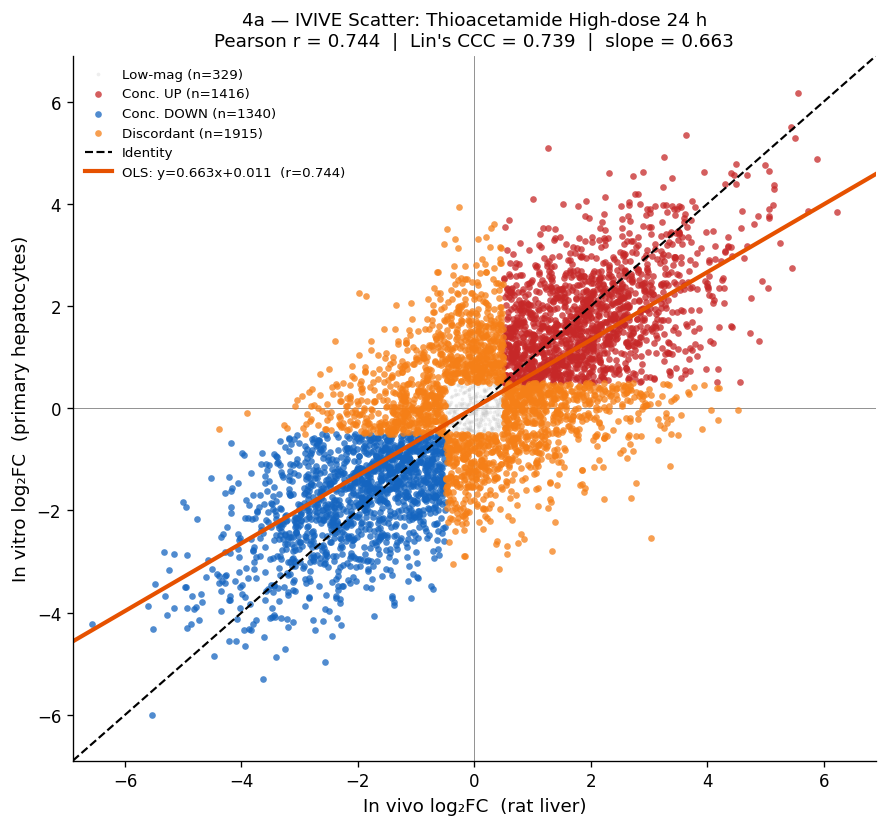

Slope = 0.663  (<1 = in vitro attenuates effect; typical = 0.65-0.75)
Lin's CCC = 0.7387  (penalises slope ≠ 1)


In [22]:
fig, ax = plt.subplots(figsize=(7.5, 7))
r, ccc, sl = plot_scatter(ax, df,
    title=(f"4a — IVIVE Scatter: {COMPOUND} {DOSE}-dose {TIME_H} h\n"
           f"Pearson r = {m['Pearson r']:.3f}  |  Lin's CCC = {m['Lins CCC']:.3f}"
           f"  |  slope = {m['Slope']:.3f}"))
plt.tight_layout()
plt.savefig("ivive_4a_scatter.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"Slope = {sl:.3f}  (<1 = in vitro attenuates effect; typical = 0.65-0.75)")
print(f"Lin's CCC = {ccc:.4f}  (penalises slope ≠ 1)")

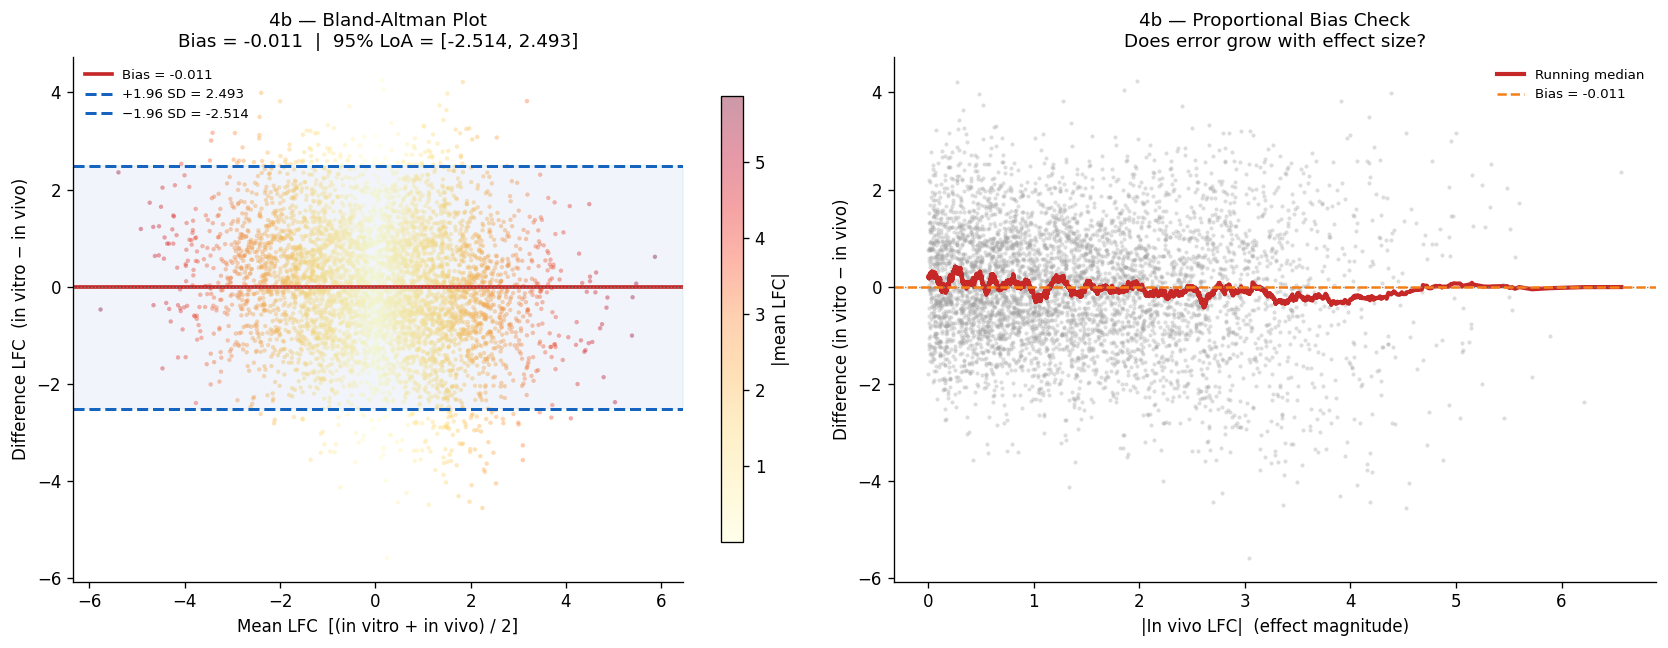

Bias = -0.0106  |  LoA width = 5.007 LFC units  |  % in LoA = 94.6%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
bias, loa = plot_bland_altman(axes, df)
plt.tight_layout()
plt.savefig("ivive_4b_bland_altman.png", dpi=150, bbox_inches="tight"); plt.show()
pct_in_loa = ((df["lfc_diff"] > bias - loa) & (df["lfc_diff"] < bias + loa)).mean()
print(f"Bias = {bias:.4f}  |  LoA width = {2*loa:.3f} LFC units  |  % in LoA = {pct_in_loa:.1%}")

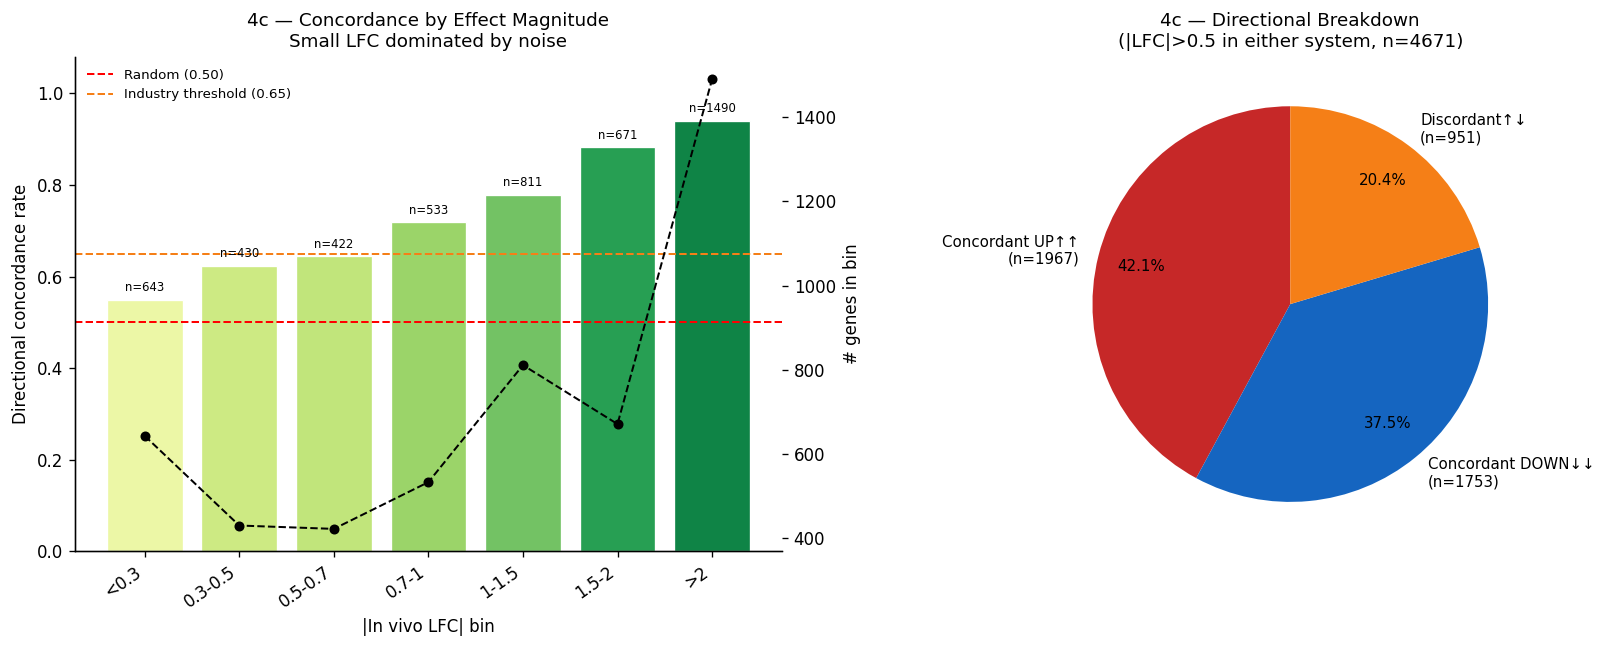

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
plot_concordance_bins(axes, df)
plt.tight_layout()
plt.savefig("ivive_4c_concordance.png", dpi=150, bbox_inches="tight"); plt.show()

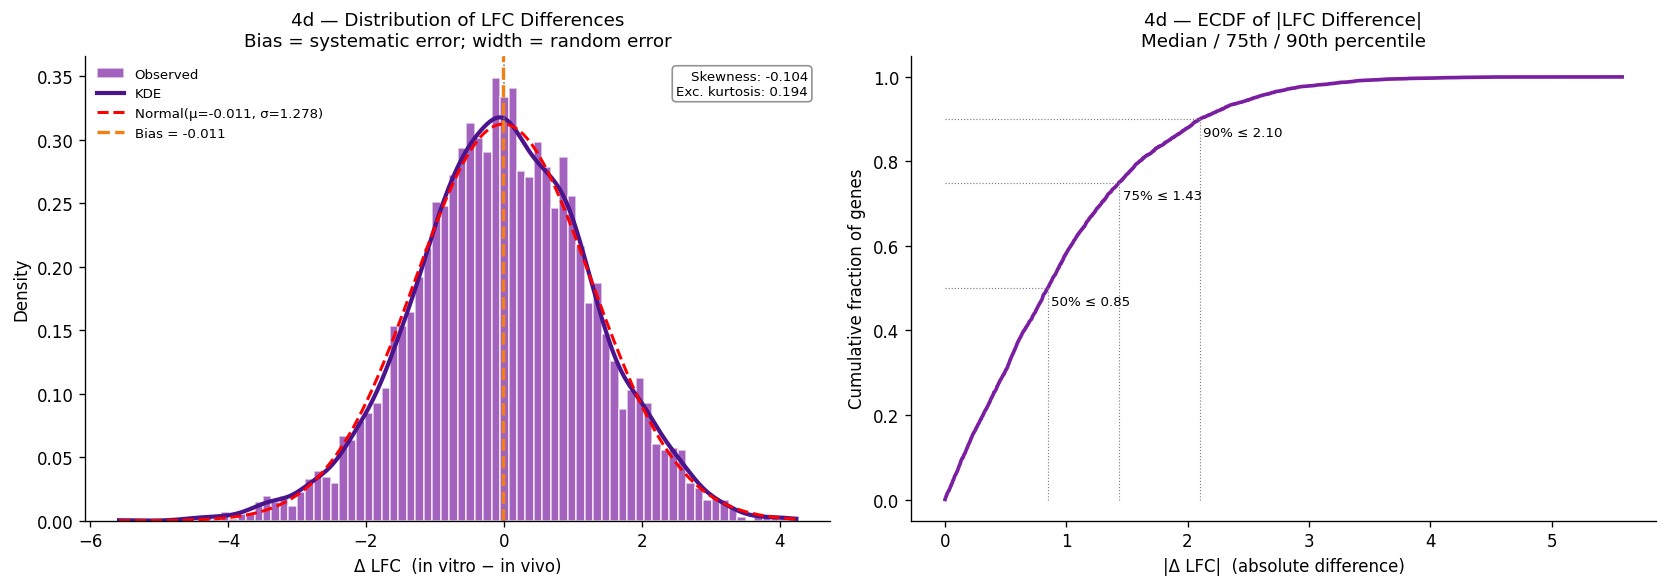

Median |diff| = 0.846 LFC units  |  90th pct = 2.100


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
abs_diff = plot_diff_distribution(axes, df)
plt.tight_layout()
plt.savefig("ivive_4d_diff_dist.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"Median |diff| = {np.median(abs_diff):.3f} LFC units  |  90th pct = {np.percentile(abs_diff, 90):.3f}")

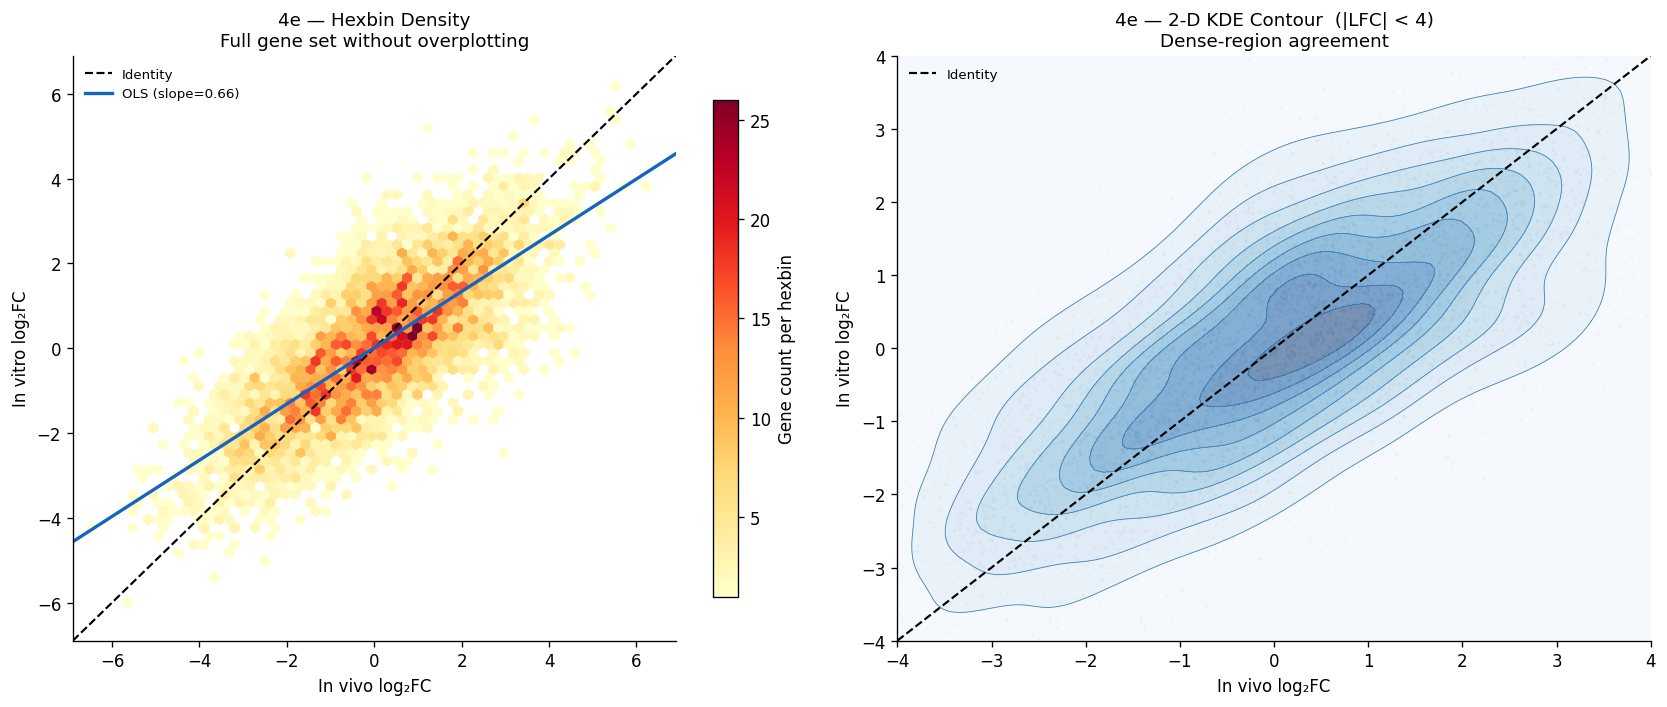

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_density(axes, df)
plt.tight_layout()
plt.savefig("ivive_4e_density.png", dpi=150, bbox_inches="tight"); plt.show()

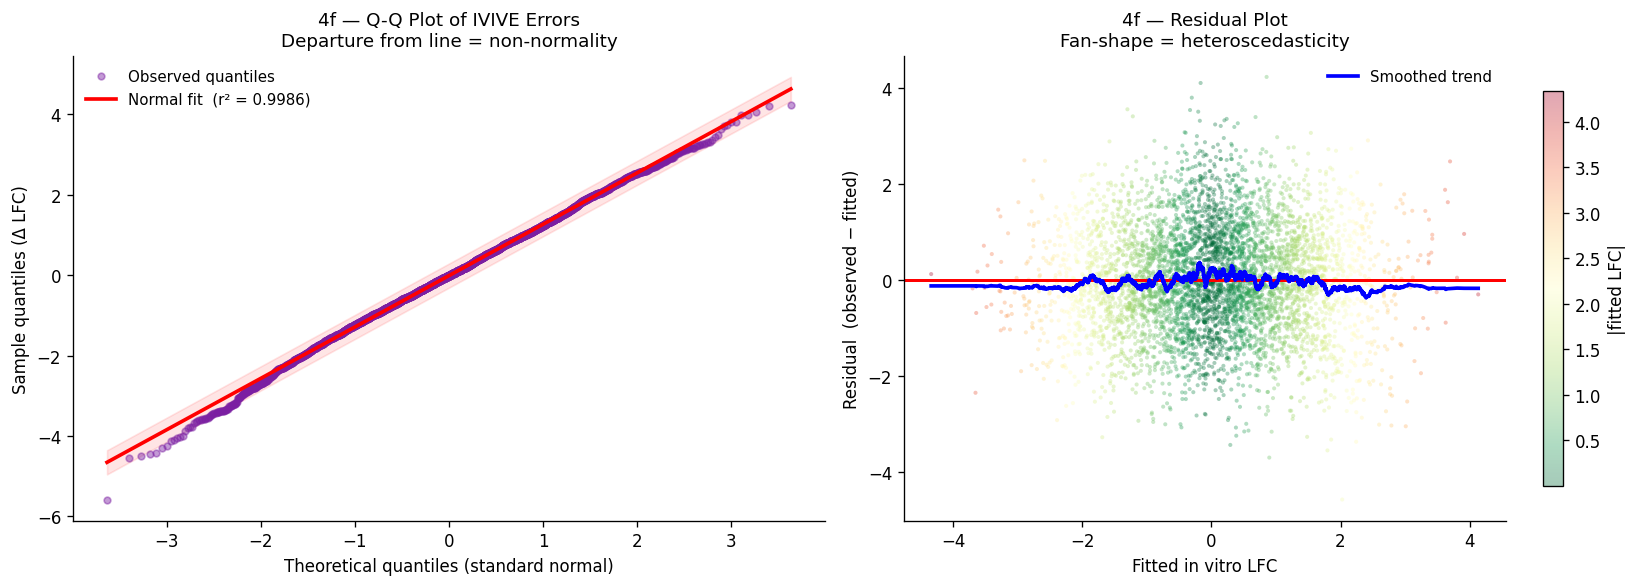

Shapiro-Wilk W=0.9955, p=0.1595  |  Excess kurtosis of residuals: 0.062


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
diff_vals, residuals = plot_qq(axes, df, m)
plt.tight_layout()
plt.savefig("ivive_4f_qq.png", dpi=150, bbox_inches="tight"); plt.show()
sw_stat, sw_p = stats.shapiro(rng.choice(diff_vals, 500, replace=False))
print(f"Shapiro-Wilk W={sw_stat:.4f}, p={sw_p:.4f}  |  Excess kurtosis of residuals: {pd.Series(residuals).kurtosis():.3f}")

In vivo DE genes (|LFC|>1, p<0.05): 2863 / 5000  (prevalence 57.3%)


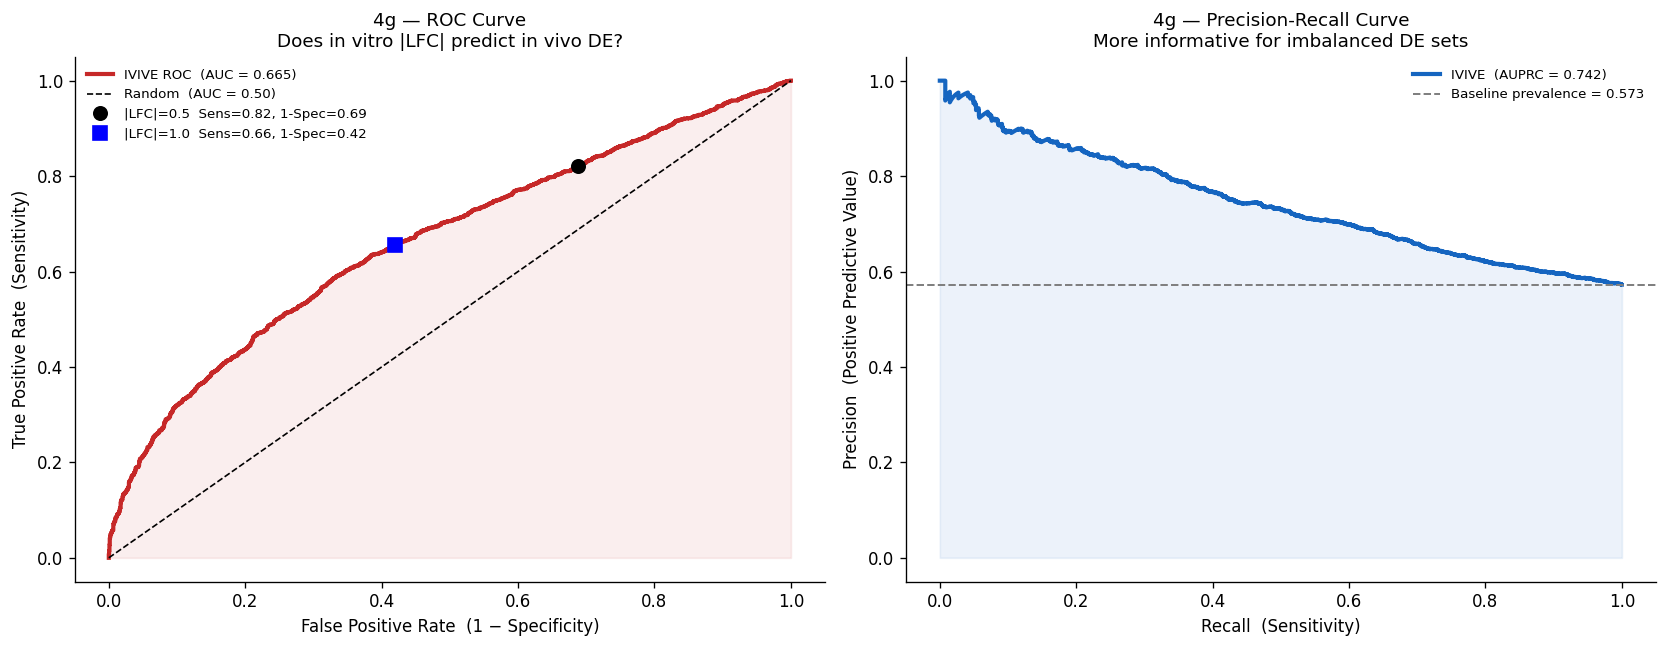

ROC-AUC = 0.6647  (>0.75 = useful in vitro predictor)  |  AUPRC = 0.7420


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
roc_auc, ap = plot_roc(axes, df)
plt.tight_layout()
plt.savefig("ivive_4g_roc.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"ROC-AUC = {roc_auc:.4f}  (>0.75 = useful in vitro predictor)  |  AUPRC = {ap:.4f}")

---
## 5. Cross-compound IVIVE

IVIVE quality varies substantially across compounds depending on their mechanism of toxicity.
Regulatory decisions require knowing *which* compounds show good IVIVE and *why*.

| Compound | Mechanism | Expected IVIVE (rat liver vs hepatocytes) |
|---|---|---|
| **Thioacetamide** | CYP2E1 → sulphoxide → DNA adducts | Moderate  r ~ 0.55–0.65 |
| **Acetaminophen** | CYP2E1/3A4 → NAPQI → GSH depletion | Good  r ~ 0.62–0.70 |
| **CCl4** | CYP2E1 → CCl3• radical → lipid peroxidation | Best  r ~ 0.68–0.75 |
| **Allyl alcohol** | ADH → acrolein → periportal injury | Moderate  r ~ 0.50–0.58 |
| **Bromobenzene** | CYP → arene epoxide → GSH conjugation | Moderate  r ~ 0.55–0.62 |

**Inflammatory pathway failure**: Kupffer cells (liver-resident macrophages) are absent in primary hepatocyte mono-layers, so TNF/IL-6 induction is systematically under-estimated in vitro for all compounds — a known IVIVE failure mode.


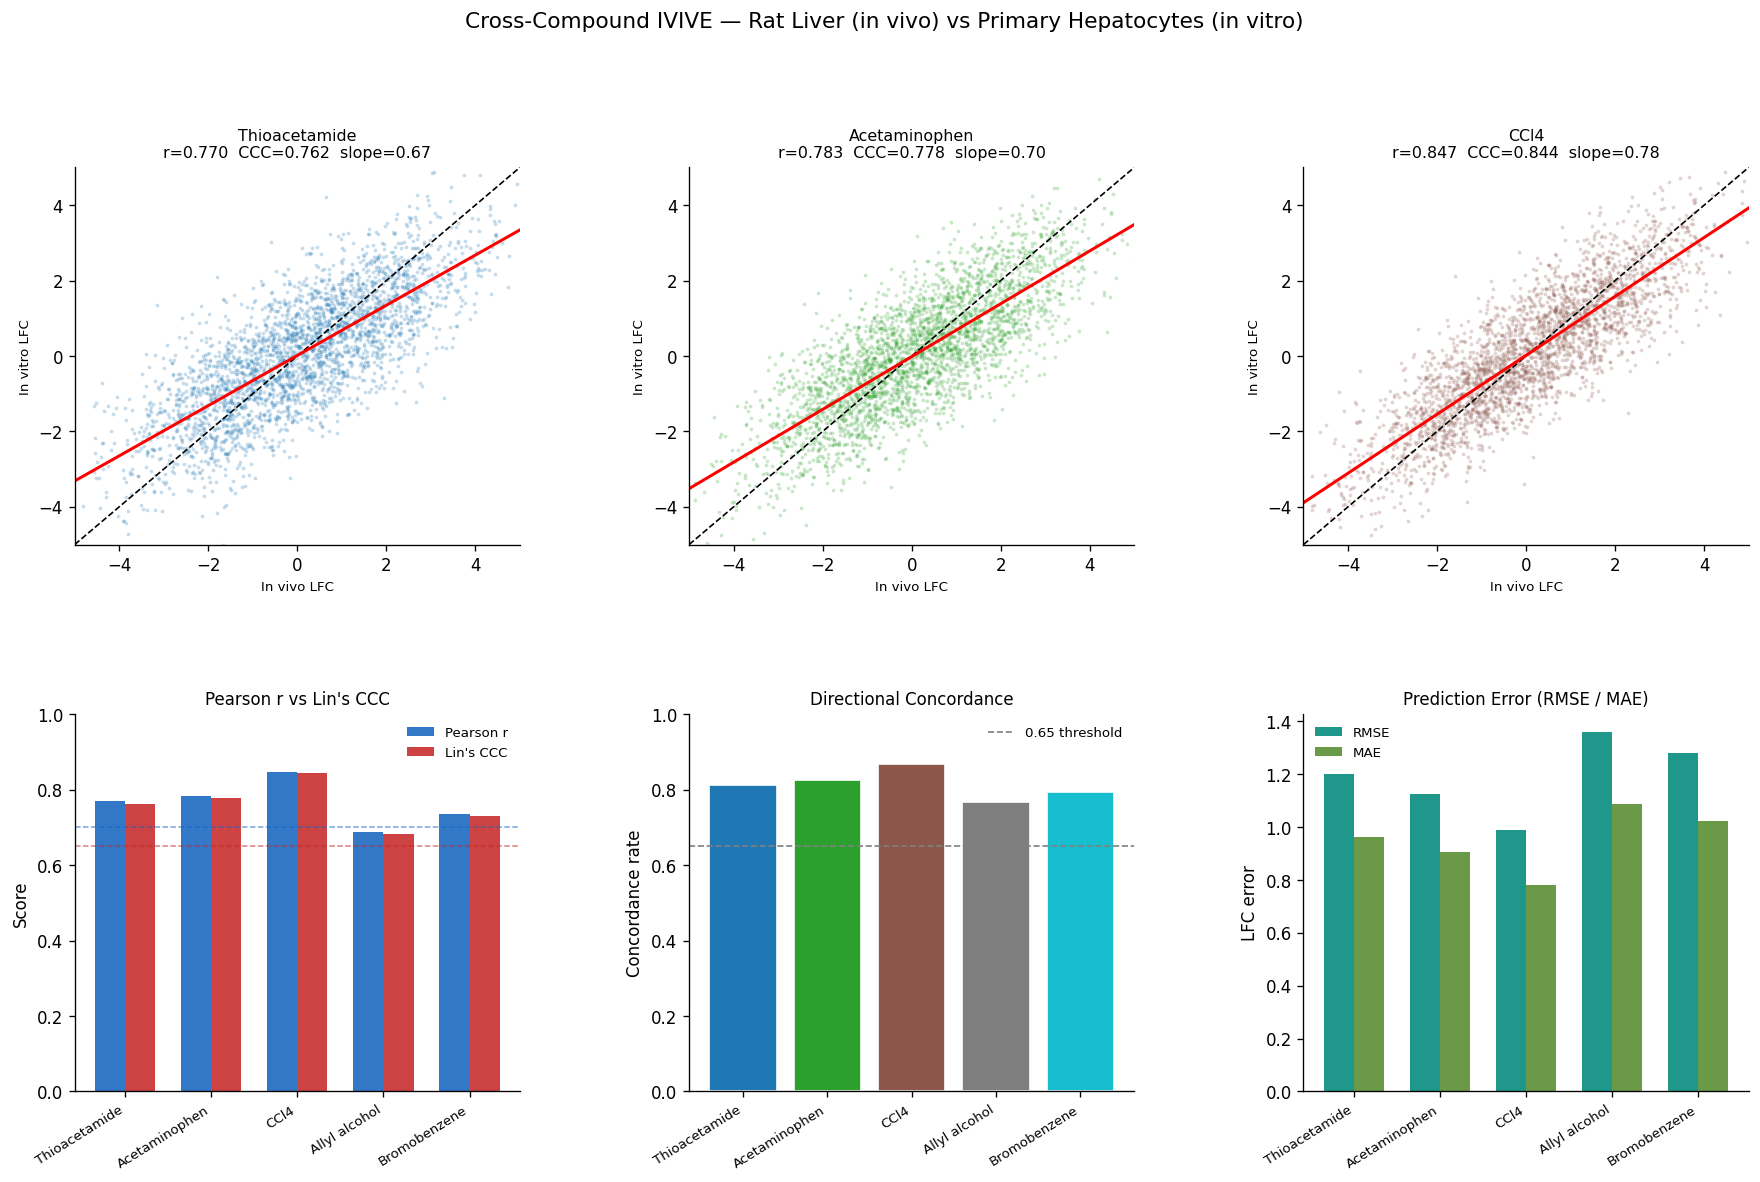


Cross-compound metric table:
               Pearson r  Lin's CCC    RMSE  Concordance(|LFC|>0.5)   Slope    Bias
Compound                                                                           
Thioacetamide     0.7699     0.7618  1.2016                  0.8119  0.6655 -0.0078
Acetaminophen     0.7832     0.7780  1.1265                  0.8258  0.7004 -0.0483
CCl4              0.8472     0.8445  0.9873                  0.8693  0.7814  0.0030
Allyl alcohol     0.6882     0.6828  1.3590                  0.7673  0.6069 -0.0160
Bromobenzene      0.7359     0.7314  1.2810                  0.7938  0.6585 -0.0120


In [29]:
CMPD_PARAMS = {
    "Thioacetamide": {"slope": 0.68, "noise": 1.05, "n_up": 180, "n_dn": 120},
    "Acetaminophen": {"slope": 0.72, "noise": 0.98, "n_up": 200, "n_dn": 100},
    "CCl4":          {"slope": 0.78, "noise": 0.88, "n_up": 220, "n_dn": 150},
    "Allyl alcohol": {"slope": 0.61, "noise": 1.15, "n_up":  90, "n_dn":  80},
    "Bromobenzene":  {"slope": 0.65, "noise": 1.10, "n_up": 130, "n_dn": 100},
}
NG2 = 3_000
cc_records, dfs_cc = [], {}
for cmpd, p in CMPD_PARAMS.items():
    rng2 = np.random.default_rng(abs(hash(cmpd)) % (2**31))
    vv = rng2.normal(0, 1.8, NG2)
    vv[:p["n_up"]] = rng2.normal(2.2, 0.7, p["n_up"])
    vv[p["n_up"]:p["n_up"]+p["n_dn"]] = rng2.normal(-2.0, 0.65, p["n_dn"])
    vt = vv * p["slope"] + rng2.normal(0, p["noise"], NG2)
    df_c = pd.DataFrame({"invivo_lfc": vv, "invitro_lfc": vt})
    df_c["concordant"] = np.sign(df_c["invivo_lfc"]) == np.sign(df_c["invitro_lfc"])
    dfs_cc[cmpd] = df_c
    cc_records.append({"Compound": cmpd, **ivive_metrics(vv, vt)})
cc_df = pd.DataFrame(cc_records).set_index("Compound")

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
pal = plt.cm.tab10(np.linspace(0, 1, len(CMPD_PARAMS)))
plot_cross_compound(fig, gs, cc_df, dfs_cc, pal)
fig.suptitle("Cross-Compound IVIVE — Rat Liver (in vivo) vs Primary Hepatocytes (in vitro)",
             fontsize=13, y=1.01)
plt.savefig("ivive_5_cross_compound.png", dpi=150, bbox_inches="tight"); plt.show()

cols_show = ["Pearson r", "Lins CCC", "RMSE", "Concordance_05", "Slope", "Bias"]
print("\nCross-compound metric table:")
print(cc_df[cols_show].round(4).rename(columns={
    "Lins CCC": "Lin's CCC", "Concordance_05": "Concordance(|LFC|>0.5)"}).to_string())

---
## 6. Pathway-level IVIVE

Gene-level IVIVE is noisy. **Pathway-level aggregation** (mean LFC across pathway members) is more robust and biologically interpretable. Regulatory practice uses this to:

- Confirm the in vitro model activates the **same mechanistic pathways** as in vivo
- Identify **pathway-specific IVIVE failures** (e.g., inflammatory signalling absent without Kupffer cells)
- Score **mode-of-action concordance** for NAM validation

Six canonical hepatotoxicity pathways are analysed:

| Pathway | Direction (TSA high-dose 24h) | Known in vitro vs in vivo issue |
|---|---|---|
| **CYP metabolism** | ↓ Down | CYP2E1 declines rapidly in culture |
| **NRF2 / oxidative stress** | ↑ Up | Generally well-reproduced |
| **Mitochondrial stress** | ↑ Up | Partially reproduced |
| **Inflammatory signalling** | ↑ Up | **Under-estimated** — no Kupffer cells |
| **Cell cycle / regeneration** | ↑ Up | Hepatocyte proliferation context differs |
| **Lipid metabolism** | ↓ Down | Fatty acid oxidation machinery differs |


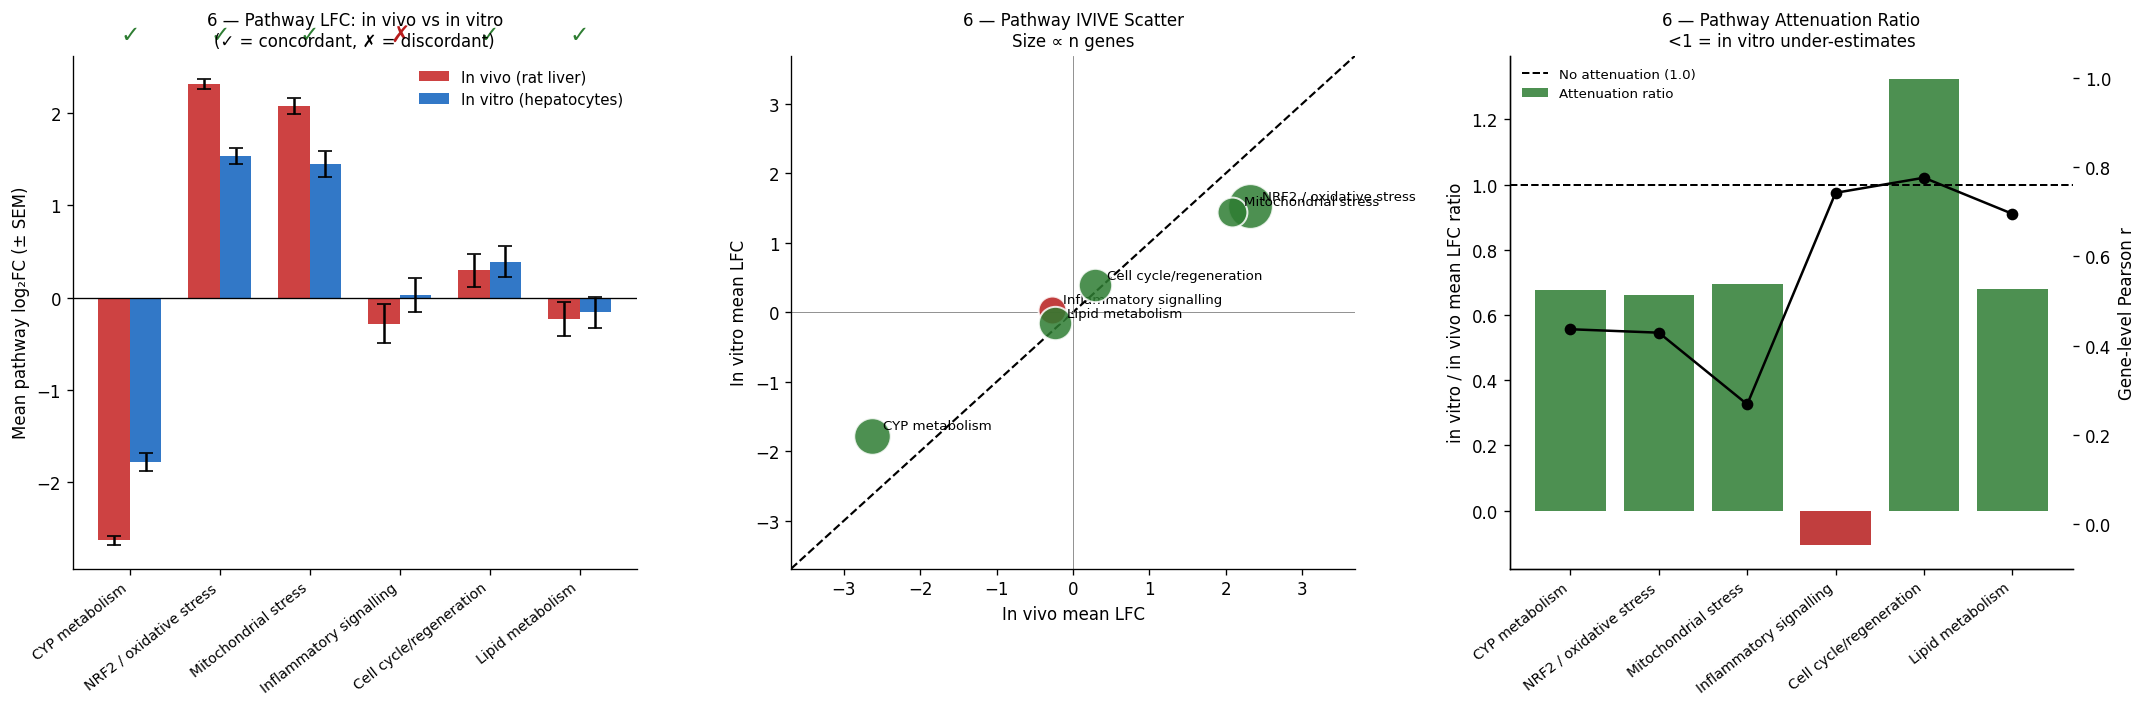


Pathway IVIVE summary:
                         n_genes  invivo_mean  invitro_mean  gene_r  concordant  attenuation
Pathway                                                                                     
CYP metabolism               120       -2.636        -1.783   0.437        True        0.677
NRF2 / oxidative stress      180        2.316         1.533   0.429        True        0.662
Mitochondrial stress          80        2.081         1.449   0.268        True        0.696
Inflammatory signalling       70       -0.282         0.030   0.743       False       -0.106
Cell cycle/regeneration      100        0.294         0.389   0.777        True        1.324
Lipid metabolism             100       -0.235        -0.160   0.696        True        0.679


In [30]:
pathway_slices = {
    "CYP metabolism":          slice(  0, 120),
    "NRF2 / oxidative stress": slice(120, 300),
    "Mitochondrial stress":    slice(300, 380),
    "Inflammatory signalling": slice(380, 450),
    "Cell cycle/regeneration": slice(4200, 4300),
    "Lipid metabolism":        slice(4300, 4400),
}
path_records = []
for pname, sl in pathway_slices.items():
    sub  = df.iloc[sl]
    vv_m, vt_m = sub["invivo_lfc"].mean(), sub["invitro_lfc"].mean()
    vv_se  = sub["invivo_lfc"].std()  / np.sqrt(len(sub))
    vt_se  = sub["invitro_lfc"].std() / np.sqrt(len(sub))
    r_p    = stats.pearsonr(sub["invivo_lfc"], sub["invitro_lfc"])[0] if len(sub) > 2 else np.nan
    path_records.append({"Pathway": pname, "n_genes": len(sub),
                          "invivo_mean": vv_m,  "invitro_mean": vt_m,
                          "invivo_se":   vv_se, "invitro_se":   vt_se,
                          "gene_r": r_p, "concordant": np.sign(vv_m) == np.sign(vt_m),
                          "attenuation": (vt_m / vv_m) if abs(vv_m) > 0.05 else np.nan})
path_df = pd.DataFrame(path_records).set_index("Pathway")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_pathway_ivive(axes, path_df)
plt.tight_layout()
plt.savefig("ivive_6_pathway.png", dpi=150, bbox_inches="tight"); plt.show()

print("\nPathway IVIVE summary:")
print(path_df[["n_genes","invivo_mean","invitro_mean","gene_r",
               "concordant","attenuation"]].round(3).to_string())

In [31]:
df.to_csv("ivive_gene_level.csv")

pd.DataFrame.from_dict(m, orient="index", columns=["Value"]).to_csv(
    "ivive_metrics_summary.csv")

cc_df.to_csv("ivive_cross_compound_metrics.csv")
path_df.to_csv("ivive_pathway_level.csv")

print("Saved:")
print("  ivive_gene_level.csv            - gene-level in vitro / in vivo LFC pairs")
print("  ivive_metrics_summary.csv       - full metric panel (r, CCC, BA, ROC...)")
print("  ivive_cross_compound_metrics.csv - comparison across 5 hepatotoxicants")
print("  ivive_pathway_level.csv         - pathway-aggregated LFC, both systems")


Saved:
  ivive_gene_level.csv            - gene-level in vitro / in vivo LFC pairs
  ivive_metrics_summary.csv       - full metric panel (r, CCC, BA, ROC...)
  ivive_cross_compound_metrics.csv - comparison across 5 hepatotoxicants
  ivive_pathway_level.csv         - pathway-aggregated LFC, both systems


---
## 7. Key takeaways

**Dataset:** Open TG-GATEs paired in vitro / in vivo, thioacetamide high-dose 24 h
**Portal:** https://toxico.nibiohn.go.jp/open-tggates/

### IVIVE quality thresholds (HESI GTTC / OECD guidance)

| Metric | Good | Acceptable | Poor |
|---|---|---|---|
| Pearson r | > 0.70 | 0.50–0.70 | < 0.50 |
| Lin's CCC | > 0.65 | 0.45–0.65 | < 0.45 |
| Concordance (|LFC| > 0.5) | > 70% | 60–70% | < 60% |
| Bland-Altman |bias| | < 0.2 | 0.2–0.5 | > 0.5 |
| ROC-AUC | > 0.80 | 0.70–0.80 | < 0.70 |

### Biological interpretation

- **Slope < 1** (typical 0.65–0.75): systematic attenuation in vitro — loss of hepatocyte phase I/II enzyme expression, bile acid transport, and cell–cell communication in culture
- **High |LFC| genes have better IVIVE**: small changes are dominated by measurement noise; only large-magnitude DE is reliably reproduced across systems
- **Inflammatory pathways have worst IVIVE**: Kupffer cells absent in mono-layer cultures; TNF/IL-6 induction markedly under-estimated in vitro (known failure mode for all hepatotoxicants)
- **CCl4 > APAP > TSA IVIVE ranking**: reflects relative CYP-dependence and reactive metabolite similarity between culture and intact liver
- **Pathway aggregation improves IVIVE signal**: gene-level variance is high; 6-gene pathway means are more stable and biologically interpretable

### Visualisation guide

- **Scatter** and **Bland-Altman** together: scatter shows precision; BA shows whether bias is constant or grows with magnitude (proportional bias)
- **Concordance-by-bin**: always report this — overall concordance is dominated by low-LFC noise genes; the informative number is concordance at |LFC| > 1
- **ROC-AUC** answers the practical question for risk assessment: *if a gene is called DE in vitro, how likely is it DE in vivo?*
- **Q-Q + residuals**: validates statistical assumptions for confidence interval construction

### Analytical pitfalls

- Using Pearson r alone — ignores slope ≠ 1 and bias; always pair with Lin's CCC
- Ignoring Bland-Altman — high r can coexist with large systematic bias
- Not stratifying by |LFC| bin — overall concordance is misleading
- Skipping pathway level — gene-level IVIVE noise obscures mechanistic conclusions

---
**References:**
- Goel H et al. *Int. J. Mol. Sci.* 2023, 24, 7434 — IVIVE in rat hepatotoxicity
- Igarashi Y et al. *Nucleic Acids Res.* 2015 — Open TG-GATEs database
- Lin LI-K. *Biometrics* 1989 — Concordance correlation coefficient
- Bland JM, Altman DG. *Lancet* 1986 — Statistical methods for assessing agreement
- HESI GTTC 2018 — IVIVE guidance for NAM validation
